# Streaming fresh minibatches

The memorization benchmark reused one minibatch for the whole run, so it measured raw
optimization power on a fixed objective. Here a fresh minibatch is drawn every step
instead, so the run is actually training on CIFAR-10 and the question becomes
generalization: how low does the held-out loss go, and how fast? I cross three methods
with three activations, matching the memorization benchmark: the trust-region optimizer,
the same trust region built on the Gauss-Newton matrix rather than the Hessian, and plain
SGD. The signal to read is the loss on a fixed held-out probe batch, not the training
loss, because the training loss is measured on a different minibatch every step and is
too noisy to follow.

## The configuration

The model and data match the memorization benchmark exactly, and the only change is
dropping `--reuse-batch`, so a new minibatch is drawn every step:

```
--image-size 8 --hidden-dim 8 --num-layers 16 --batch-size 32 --seed 0 --data-dir ./data
```

There are nine runs, three methods crossed with tanh, gelu and relu. The trust-region
runs use the dense subproblem solver,
`--mode trust-region --tr-solver dense --delta-init 1.0 --delta-max 100 --tr-eta 0.1 --num-steps 400`,
and sweeping the trust-radius and acceptance parameters on this streaming task did not
move them, so they keep the radius that worked for memorization. The Gauss-Newton runs
add `--curvature ggn` to those same arguments and change nothing else, so the only thing
separating them from the trust-region runs is which matrix the subproblem is built on:
the Hessian, which is indefinite away from a minimum, or `G = J'ΛJ`, which drops the
network's own curvature and is therefore positive semidefinite. The SGD runs use
`--mode sgd --num-steps 30000` with the learning rate swept on this streaming objective
rather than carried over, because the best rate differs from memorization's: tanh 0.03,
gelu 0.1, relu 0.1. The exact args live in `streaming/experiments.py`, which both `run.py`
and `plot.py` import.

## Running it

The figure below renders inline from the committed CSVs. To regenerate the data, run
`python benchmarks/streaming/run.py` from the repo root using the project venv. That
script launches `src/train_newton.py` once per config, parses its per-step stderr, and
writes `streaming/results/<name>.csv` with columns
`step,train_loss,probe_loss,probe_accuracy,wall_clock_s`. The cell below then renders the
figure by importing `plot`.

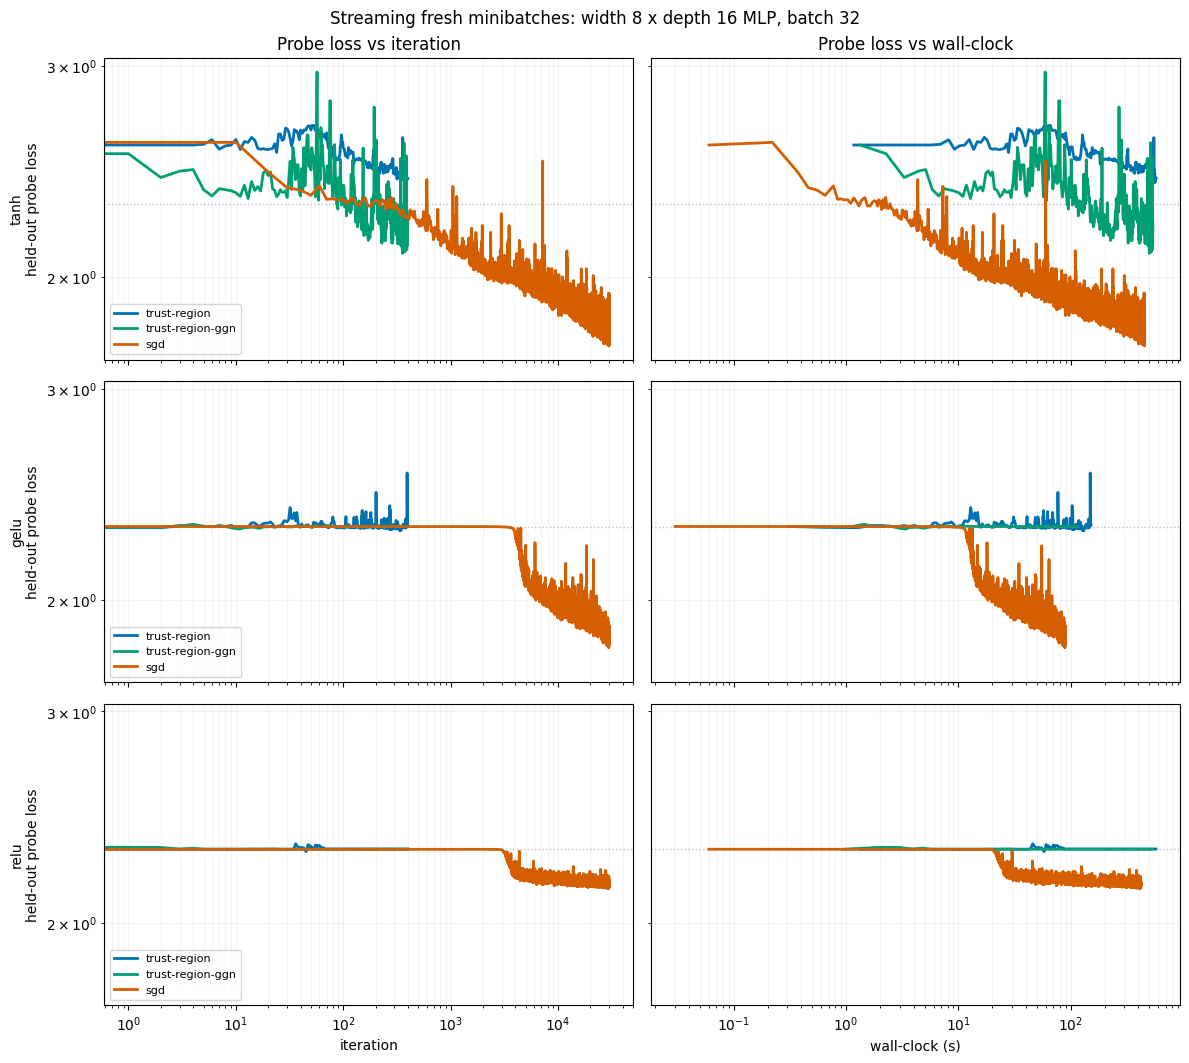

In [1]:
import pathlib, sys

for cand in (pathlib.Path.cwd() / "streaming",
             pathlib.Path.cwd() / "benchmarks" / "streaming"):
    if cand.exists():
        sys.path.insert(0, str(cand))
        break

%matplotlib inline
import plot

fig = plot.build_figure()

## The result

| Activation | trust-region | trust-region-ggn | sgd    |
|------------|--------------|------------------|--------|
| tanh       | 2.3977       | 2.0936           | 1.7524 |
| gelu       | 2.2844       | 2.2916           | 1.8247 |
| relu       | 2.2920       | 2.3026           | 2.1342 |

Best held-out probe loss over the run; the random-guess loss is ln(10) ≈ 2.3026. SGD's
best probe accuracies are 0.371, 0.336 and 0.199, against 0.156, 0.148 and 0.145 for
trust-region and 0.230, 0.176 and 0.086 for Gauss-Newton.

The result flips from the memorization benchmark, because here SGD wins on every
activation. Neither curvature method gets close: trust-region on tanh ends at 2.3977,
which is worse than guessing, and Gauss-Newton on relu ends at exactly 2.3026, meaning it
never moved at all. The runs take very different iteration counts, so the wall-clock panel
is the fair comparison, and there SGD is far ahead as well.

This is the minibatch-noise effect from the stochastic-optimization literature. The
trust-region step is computed from one noisy minibatch and its acceptance ratio is checked
on that same batch, so it fits the curvature of a different objective every step, and a
second-order method loses its edge once the gradient and Hessian are dominated by that
noise. Sweeping the trust-region radius and acceptance threshold did not change this,
which says the stall is the noise rather than the tuning. The memorization benchmark
removed the noise by reusing one batch, which is exactly why trust-region won there and
loses here.

Which curvature matrix is better depends on the activation, and the ordering is the
reverse of memorization's. There the Hessian beat `G` decisively on tanh and gelu; here
`G` beats the Hessian on tanh by a wide margin, 2.0936 against 2.3977, they tie on gelu,
and the Hessian wins on relu. The tanh case is the interesting one, because the Hessian
run is worse than not training at all while `G` at least descends, which is what you would
expect if the harm comes from the noisy Hessian's indefiniteness. I have not tested that
mechanism directly, so it remains an explanation rather than a finding.

Two caveats on the timings. The tanh and relu runs were launched six at a time, so their
wall-clock is inflated by contention relative to the gelu runs, which ran alone; the
right-hand panels are therefore not comparable across rows. And the Gauss-Newton runs
reuse the trust-region hyperparameters unchanged, which is what keeps the comparison
controlled but leaves `G` untuned.